<h1><center>Recommender Systems YSDA Course!</center></h1>
<h1><center>Семинар №2</center></h1>

<center><img src="https://github.com/Lizavetka99/RecSys-ysda/blob/main/logo.jpg?raw=1" width="500" /></center>

**В этом семинаре мы:**
- Познакомимся с датасетом YAMBDA
- Ссылка на оригинальный датасет: https://huggingface.co/datasets/yandex/yambda
- Посмотрим на контест курса: https://www.kaggle.com/competitions/ysda-rec-sys-2026
- Напишем бейзлайн
- Обучим более сложные модели (CatBoost)
- Напишем несколько новых метрик оценки качества ранжирования

**Баллы за пороги:**
- 5 баллов за пробитие 0.06
- 10 баллов за ...
- 15 баллов за ...
- Топ 3 - дополнительные 10 баллов
- Топ 10 - дополнительные 5 баллов

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool

# 🗄 Датасет:

In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "likes.parquet"

data = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
)

data = data.with_columns(
    pl.col("uid").cast(pl.UInt32),
    pl.col("item_id").cast(pl.UInt32),
)

data

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


In [8]:
item_ids = data.select(pl.col("item_id").unique()).collect()
item_ids

item_id
u32
7
12
17
22
26
…
9390601
9390604
9390611


In [9]:
file_path = "test_users.csv"

test_users = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

test_users

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


uid
i64
89
153
164
216
291
…
999735
999737
999779


In [10]:
file_path = "artist_item_mapping_small.parquet"

artists = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

artists = artists.with_columns(
    pl.col("item_id").cast(pl.UInt32),
    pl.col("artist_id").cast(pl.UInt32),
)

artists

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


artist_id,item_id
u32,u32
2,6990698
4,4427862
5,7240336
8,8639916
12,7016394
…,…
1293380,7614966
1293385,2465805
1293389,1958584


# 👀 Смотрим на датасет, знакомимся

In [12]:
print('min timestamp: ', data.select(pl.col("timestamp").min()).collect().item())
print('max timestamp: ', data.select(pl.col("timestamp").max()).collect().item())

min timestamp:  0
max timestamp:  26000000


In [ ]:
print('count days: ', (data.max()['timestamp'] - data.min()['timestamp']).item() / 24 / 60 / 60)

count days:  300.9255787037037


In [ ]:
data['uid'].unique().count()

364350

In [ ]:
data['item_id'].unique().count()

202604

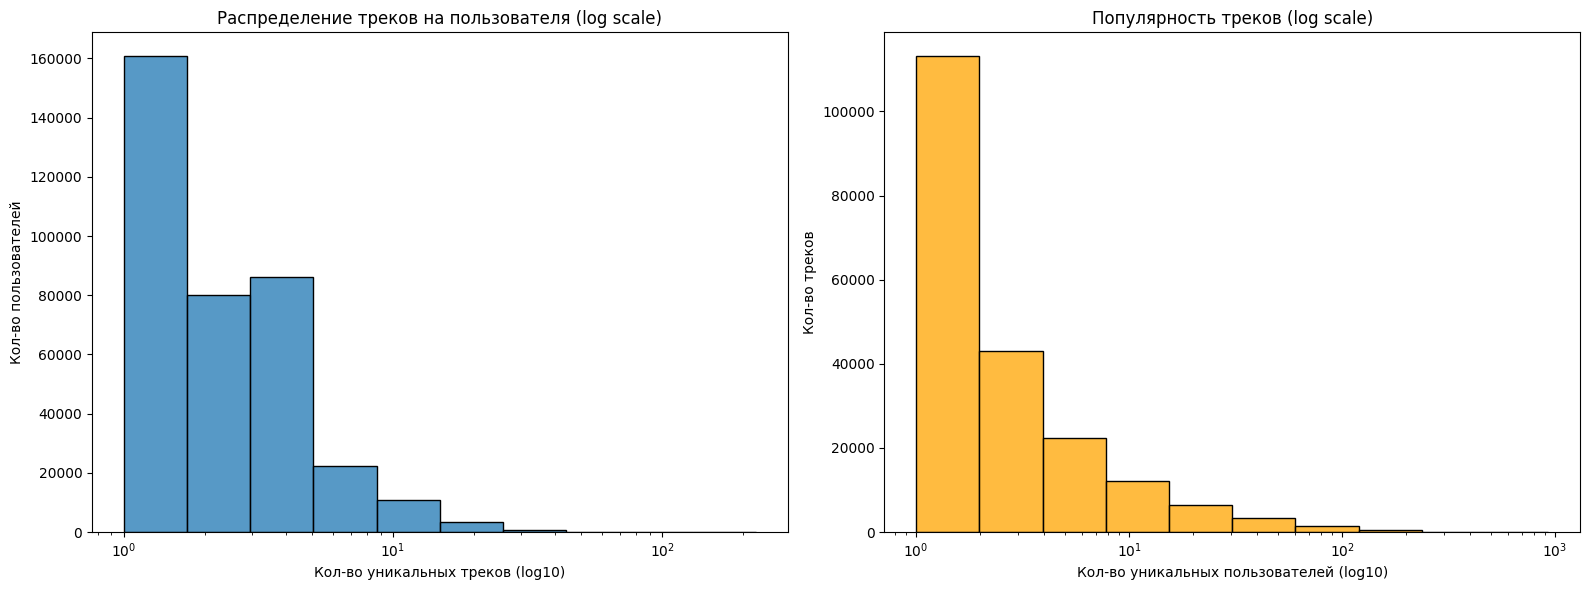

In [ ]:
tracks_per_user = data.group_by("uid").agg(
    pl.col("item_id").n_unique().alias("count")
)
users_per_track = data.group_by("item_id").agg(
    pl.col("uid").n_unique().alias("count")
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=tracks_per_user, x="count", bins=10, ax=ax[0], log_scale=True)
ax[0].set_title("Распределение треков на пользователя (log scale)")
ax[0].set_xlabel("Кол-во уникальных треков (log10)")
ax[0].set_ylabel("Кол-во пользователей")

sns.histplot(data=users_per_track, x="count", bins=10, ax=ax[1], color="orange", log_scale=True)
ax[1].set_title("Популярность треков (log scale)")
ax[1].set_xlabel("Кол-во уникальных пользователей (log10)")
ax[1].set_ylabel("Кол-во треков")

plt.tight_layout()
plt.show()

In [ ]:
print('is_organic share: ', data['is_organic'].mean())

is_organic share:  0.575914


# 📈 Бейзлайн: самые лайкаемые треки

In [13]:
popular_tracks = (
    data
    .group_by("item_id")
    .agg(pl.len())
    .sort("len", descending=True)
    .head(1000)
    .collect()
)

In [14]:
popular_tracks_strs = []

for i in popular_tracks:
    popular_tracks_strs.append(str(i))

ans = ' '.join(popular_tracks_strs)

test_users = test_users.with_columns(
    pl.lit(ans).alias("item_ids")
)

test_users.write_csv('baseline.csv')

test_users # скор ~ 0.024

uid,item_ids
i64,str
89,"""shape: (1_000,) Series: 'item_…"
153,"""shape: (1_000,) Series: 'item_…"
164,"""shape: (1_000,) Series: 'item_…"
216,"""shape: (1_000,) Series: 'item_…"
291,"""shape: (1_000,) Series: 'item_…"
…,…
999735,"""shape: (1_000,) Series: 'item_…"
999737,"""shape: (1_000,) Series: 'item_…"
999779,"""shape: (1_000,) Series: 'item_…"


# 🦾 CatBoost

<center><img src="https://github.com/Lizavetka99/RecSys-ysda/blob/main/Timesplit1.svg?raw=1" width="1100" /></center>


Давайте соберём какие-то фичи из данных и обучим на них градиентный бустинг. Нужно не забывать про временные лики. Нельзя давать модели видеть данные из будущего, поэтому фичи для каждого семпла должны быть посчитаны на данных из прошлого. В простейшей схеме предлагается разделить размеченые данные на 3 части:
- Вторая часть - train
- Третья часть - validation
- Первую часть используем для расчёта статистик для трейна
- Для валидации считаем статистики используя первую и вторую части вместе

#### Делим data на 3 части:

In [15]:
DAY = 24 * 3600
WINDOW_DAYS = 120

max_ts = data.select(pl.col("timestamp").max()).collect().item()

data = data.filter(
    pl.col("timestamp") > max_ts - WINDOW_DAYS * DAY
)

In [17]:
n_rows = data.select(pl.len()).collect().item()
data_len_div3 = n_rows // 3

data = data.sort("timestamp")

data_part1 = data.slice(0, data_len_div3)
data_part2 = data.slice(data_len_div3, data_len_div3)
data_part3 = data.slice(data_len_div3 * 2, data_len_div3)

#### Набираем негативы:

In [19]:
def add_popular_random_negatives(
    pool_df: pl.LazyFrame,
    df: pl.LazyFrame,
    k: int,
    top_n: int = 10000,
    seed: int = 42,
):

    # популярные треки
    top_items = (
        pool_df
        .group_by("item_id")
        .len()
        .sort("len", descending=True)
        .limit(top_n)
        .select("item_id")
        .collect()
    )

    # позитивы
    pos = (
        df
        .select(["uid", "item_id"])
        .with_columns(pl.lit(1).alias("target"))
        .collect()
    )

    # негативы
    n = pos.height * k

    neg = pl.DataFrame({
        "uid": pos["uid"].repeat_by(k).explode(),
        "item_id": top_items["item_id"].sample(n=n, with_replacement=True, seed=seed),
        "target": pl.repeat(0, n, eager=True),
    })

    return pl.concat([pos, neg])
train = add_popular_random_negatives(data_part1, data_part2, 3)

#### Посчитаем популярность трека за прошлый период

In [21]:
def add_item_popularity(events, df):

    if isinstance(events, pl.LazyFrame):
        events = events.collect()

    pop = (
        events
        .group_by("item_id")
        .len()
        .rename({"len": "item_popularity"})
    )

    return (
        df.join(pop, on="item_id", how="left")
        .with_columns(pl.col("item_popularity").fill_null(0))
    )

train = add_item_popularity(data_part1, train)
train

uid,item_id,target,item_popularity
u32,u32,i32,u32
604534,4544522,1,393
607238,6375582,1,2345
682505,4064457,1,1633
843946,8732545,1,3252
859203,5703979,1,2869
…,…,…,…
161946,5758083,0,256
161946,1934057,0,639
166347,1189498,0,249


#### Кол-во лайков юзера

In [23]:
def add_user_count_likes(events, df):

    if isinstance(events, pl.LazyFrame):
        events = events.collect()

    pop = (
        events
        .group_by("uid")
        .len()
        .rename({"len": "user_count_likes"})
    )

    return (
        df.join(pop, on="uid", how="left")
        .with_columns(pl.col("user_count_likes").fill_null(0))
    )

train = add_user_count_likes(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes
u32,u32,i32,u32,u32
604534,4544522,1,393,22
607238,6375582,1,2345,27
682505,4064457,1,1633,14
843946,8732545,1,3252,81
859203,5703979,1,2869,4
…,…,…,…,…
161946,5758083,0,256,102
161946,1934057,0,639,102
166347,1189498,0,249,117


####  Доля is_organic по треку

In [24]:
def add_item_organic_share(events, df):

    if isinstance(events, pl.LazyFrame):
        events = events.collect()

    share = (
        events
        .group_by("item_id")
        .agg(pl.col("is_organic").mean().alias("item_organic_share"))
    )

    return (
        df.join(share, on="item_id", how="left")
        .with_columns(pl.col("item_organic_share").fill_null(0))
    )

train = add_item_organic_share(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share
u32,u32,i32,u32,u32,f64
604534,4544522,1,393,22,0.872774
607238,6375582,1,2345,27,0.353092
682505,4064457,1,1633,14,0.477036
843946,8732545,1,3252,81,0.523063
859203,5703979,1,2869,4,0.334611
…,…,…,…,…,…
161946,5758083,0,256,102,0.3828125
161946,1934057,0,639,102,0.458529
166347,1189498,0,249,117,0.445783


#### Доля is_organic по юзеру

In [25]:
def add_user_organic_share(events, df):

    if isinstance(events, pl.LazyFrame):
        events = events.collect()

    share = (
        events
        .group_by("uid")
        .agg(pl.col("is_organic").mean().alias("user_organic_share"))
    )

    return (
        df.join(share, on="uid", how="left")
        .with_columns(pl.col("user_organic_share").fill_null(0))
    )

train = add_user_organic_share(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share
u32,u32,i32,u32,u32,f64,f64
604534,4544522,1,393,22,0.872774,0.454545
607238,6375582,1,2345,27,0.353092,1.0
682505,4064457,1,1633,14,0.477036,0.642857
843946,8732545,1,3252,81,0.523063,0.407407
859203,5703979,1,2869,4,0.334611,1.0
…,…,…,…,…,…,…
161946,5758083,0,256,102,0.3828125,0.794118
161946,1934057,0,639,102,0.458529,0.794118
166347,1189498,0,249,117,0.445783,0.555556


In [ ]:
def add_user_artist_like_cnt(events: pl.DataFrame, df: pl.DataFrame, item2artist: pl.DataFrame) -> pl.DataFrame:
    stats = (
        events.select(["uid", "item_id"])
        .join(item2artist, on="item_id", how="left")
        .group_by(["uid", "artist_id"])
        .len()
        .rename({"len": "user_artist_like_cnt"})
    )

    return (
        df.join(item2artist, on="item_id", how="left")
          .join(stats, on=["uid", "artist_id"], how="left")
          .with_columns(pl.col("user_artist_like_cnt").fill_null(0))
          .drop('artist_id')
    )

train = add_user_artist_like_cnt(data_part1, train, artists)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,user_artist_like_cnt
u32,u32,i32,u32,u32,f64,f64,u32
361377,8170517,1,1,0,0.0,0.0,0
864626,7409645,1,39,1,0.641026,1.0,0
133536,1637620,1,15,6,0.333333,0.333333,0
779249,8916309,1,5,0,0.6,0.0,0
905262,3426714,1,7,0,0.428571,0.0,0
…,…,…,…,…,…,…,…
987610,7082966,0,13,1,0.692308,0.0,0
219064,327871,0,7,0,0.428571,0.0,0
94710,810937,0,54,1,0.37037,1.0,0


In [30]:
WINDOW_DAYS = 100
WINDOW_SEC = WINDOW_DAYS * 24 * 3600

min_ts2 = data_part2.select(pl.col("timestamp").min()).collect().item()

def add_item_popularity_window(events, df, window_sec, max_timestamp):

    if isinstance(events, pl.LazyFrame):
        events = (
            events
            .filter(pl.col("timestamp") > max_timestamp - window_sec)
            .collect()
        )
    else:
        events = events.filter(
            pl.col("timestamp") > max_timestamp - window_sec
        )

    pop = (
        events
        .group_by("item_id")
        .len()
        .rename({"len": "item_popularity_100d"})
    )

    return (
        df.join(pop, on="item_id", how="left")
        .with_columns(pl.col("item_popularity_100d").fill_null(0))
    )
train = add_item_popularity_window(
    data_part1,
    train,
    WINDOW_SEC,
    min_ts2
)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,item_popularity_100d
u32,u32,i32,u32,u32,f64,f64,u32
604534,4544522,1,393,22,0.872774,0.454545,393
607238,6375582,1,2345,27,0.353092,1.0,2345
682505,4064457,1,1633,14,0.477036,0.642857,1633
843946,8732545,1,3252,81,0.523063,0.407407,3252
859203,5703979,1,2869,4,0.334611,1.0,2869
…,…,…,…,…,…,…,…
161946,5758083,0,256,102,0.3828125,0.794118,256
161946,1934057,0,639,102,0.458529,0.794118,639
166347,1189498,0,249,117,0.445783,0.555556,249


In [32]:
def add_user_last_activity(events, df):

    events = events.collect()   # <- добавь это

    last_ts = (
        events.group_by("uid")
        .agg(pl.col("timestamp").max().alias("last_ts"))
    )

    return df.join(last_ts, on="uid", how="left")


train = add_user_last_activity(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,item_popularity_100d,last_ts
u32,u32,i32,u32,u32,f64,f64,u32,u32
604534,4544522,1,393,22,0.872774,0.454545,393,19646595
607238,6375582,1,2345,27,0.353092,1.0,2345,19646790
682505,4064457,1,1633,14,0.477036,0.642857,1633,19646790
843946,8732545,1,3252,81,0.523063,0.407407,3252,19646790
859203,5703979,1,2869,4,0.334611,1.0,2869,19646790
…,…,…,…,…,…,…,…,…
161946,5758083,0,256,102,0.3828125,0.794118,256,19611490
161946,1934057,0,639,102,0.458529,0.794118,639,19611490
166347,1189498,0,249,117,0.445783,0.555556,249,19518485


#### Проделываем то-же самое для валидации. Фичи считаем по событиям из 2 части датасета. Затем клеим их к 3 части:

In [33]:
val = add_popular_random_negatives(data_part2, data_part3, 3)
val = add_item_popularity(data_part2, val)
val = add_user_count_likes(data_part2, val)
val = add_item_organic_share(data_part2, val)
val = add_user_organic_share(data_part2, val)
#val = add_user_artist_like_cnt(data_part2, val, artists)

val = add_item_popularity_window(
    data_part2,
    val,
    WINDOW_SEC,
    min_ts2
)
val = add_user_last_activity(data_part2, val)

val

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,item_popularity_100d,last_ts
u32,u32,i32,u32,u32,f64,f64,u32,u32
180744,1526733,1,105,174,0.714286,0.637931,105,22842935
181060,4523061,1,76,19,0.934211,1.0,76,22768315
324490,6935357,1,215,107,0.576744,0.327103,215,23027730
514214,7610475,1,1537,112,0.42095,1.0,1537,23027240
514214,7565403,1,6345,112,0.530969,1.0,6345,23027240
…,…,…,…,…,…,…,…,…
411057,5757005,0,259,88,0.532819,1.0,259,23019365
411057,8871689,0,646,88,0.575851,1.0,646,23019365
631492,1960303,0,252,157,0.547619,0.267516,252,22946505


#### Обучаем катбуст:

In [ ]:
train_pool = Pool(
    data=train.drop(['target', 'item_id', 'uid']).to_pandas(),
    label=train['target'].to_list(),
)

val_pool = Pool(
    data=val.drop(['target', 'item_id', 'uid']).to_pandas(),
    label=val['target'].to_list(),
)

In [ ]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="AUC",
    early_stopping_rounds=50,
    task_type="GPU",
    verbose=50
)

model.fit(
    train_pool,
    eval_set=val_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.8301549	best: 0.8301549 (0)	total: 144ms	remaining: 14.3s
10:	test: 0.8583921	best: 0.8586060 (4)	total: 873ms	remaining: 7.06s
20:	test: 0.8582267	best: 0.8599239 (14)	total: 1.61s	remaining: 6.07s
30:	test: 0.8601637	best: 0.8603857 (27)	total: 2.39s	remaining: 5.33s
40:	test: 0.8608685	best: 0.8608685 (40)	total: 3.14s	remaining: 4.52s
50:	test: 0.8613222	best: 0.8613974 (47)	total: 3.91s	remaining: 3.76s
60:	test: 0.8616550	best: 0.8616550 (60)	total: 4.67s	remaining: 2.99s
70:	test: 0.8618140	best: 0.8618140 (70)	total: 5.42s	remaining: 2.21s
80:	test: 0.8619215	best: 0.8619462 (79)	total: 6.17s	remaining: 1.45s
90:	test: 0.8619937	best: 0.8619937 (90)	total: 6.96s	remaining: 689ms
99:	test: 0.8619931	best: 0.8620033 (92)	total: 7.66s	remaining: 0us

bestTest = 0.8620033363
bestIteration = 92

Shrink model to first 93 iterations.


#### Важности фичей:

In [ ]:
imps = model.get_feature_importance(type="PredictionValuesChange")
pairs = sorted(zip(model.feature_names_, imps), key=lambda x: x[1], reverse=True)

for name, val in pairs:
    print(f"{name}: {val}")


item_popularity: 97.37179170359616
item_organic_share: 1.1170690136255765
user_count_likes: 1.0740763774874438
user_artist_like_cnt: 0.2857254950678131
user_organic_share: 0.15133741022300196


### 🔍  Retrieval:

#### Кандидатогенератор популярных треков

In [ ]:
popular_tracks = (
    data
    .group_by("item_id")
    .len()
    .sort("len", descending=True)
    .head(500)
    .select("item_id")
    .collect()
)

user_top_artists = (
    data
    .join(artists.lazy(), on="item_id")
    .group_by(["uid", "artist_id"])
    .len()
    .sort("len", descending=True)
    .group_by("uid")
    .head(3)
    .select(["uid", "artist_id"])
    .collect()
)
artist_tracks = (
    user_top_artists
    .join(artists, on="artist_id")
    .select(["uid", "item_id"])
)

item_id
u32
5862961
3542184
9378983
6901374
5463340
…
6756182
6678692
6749531


In [ ]:
popular_candidates = test_users.select("uid").join(popular_tracks, how="cross")

artist_candidates = (
    test_users
    .join(artist_tracks, on="uid", how="left")
)

test = (
    pl.concat([popular_candidates, artist_candidates])
    .unique(["uid","item_id"])
)
test

uid,item_id
i64,u32
89,5862961
89,3542184
89,9378983
89,6901374
89,5463340
…,…
999884,6756182
999884,6678692
999884,6749531


#### Считаем фичи

In [ ]:
test = add_item_popularity(data_part3, test)
test = add_user_count_likes(data_part3, test)
test = add_item_organic_share(data_part3, test)
test = add_user_organic_share(data_part3, test)
#test = add_user_artist_like_cnt(data_part3, test, artists)

test

uid,item_id,item_popularity,user_count_likes,item_organic_share,user_organic_share,user_artist_like_cnt
i64,u32,u32,u32,f64,f64,u32
89,5862961,267,2,0.745318,1.0,0
89,3542184,386,2,0.65544,1.0,0
89,9378983,154,2,0.707792,1.0,0
89,6901374,260,2,0.707692,1.0,0
89,5463340,99,2,0.686869,1.0,0
…,…,…,…,…,…,…
999884,6756182,26,0,0.423077,0.0,0
999884,6678692,42,0,0.5,0.0,0
999884,6749531,27,0,0.518519,0.0,0


#### Применяем модель

In [ ]:
test_pool = Pool(
    data=test.drop(['item_id', 'uid']).to_pandas(),
)

In [ ]:
pred = model.predict_proba(test_pool)[:, 1]

submit = (
    test.select(["uid", "item_id"])
    .with_columns(pl.Series("pred", pred))
    .sort(["uid", "pred"], descending=[False, True])
    .group_by("uid")
    .agg(
        pl.col("item_id").head(100).cast(pl.Utf8).str.join(" ").alias("item_ids")
    )
)

submit

uid,item_ids
i64,str
89,"""7599492 3971215 4899017 736814…"
153,"""7599492 3971215 4899017 647068…"
164,"""7599492 3971215 6470688 736814…"
216,"""3971215 7599492 7368148 489901…"
291,"""3971215 7599492 6470688 489901…"
…,…
999735,"""7599492 3971215 7368148 647068…"
999737,"""3971215 7599492 7368148 489901…"
999779,"""7599492 3971215 6470688 489901…"


In [ ]:
submit.write_csv('catboost.csv') # скор ~ 0.043

### Что дальше?

- Правильная оффлайн валидация (За какие даты собран тест?)
- Правильно собранный пул для обучения
- Больше фичей (Как сделать фичи из эмбеддингов?)
- Более богатые негативы
- Более богатые кандидатогенераторы
- CatBoostClassifier?
- Гиперпараметры модели
- Больше данных
- Учиться на всех данных
<center><img src="https://github.com/Lizavetka99/RecSys-ysda/blob/main/Timesplit2.svg?raw=1" width="1100" /></center>